# What real darts says about the model

Notebook 18 built the machinery to calibrate against real scores and asked what data would
buy. This one has the data: **300,985 observed darts** of professional competition, plus
16,777 double attempts where the intended target is known.

Three predictions get tested, in ascending order of how much damage they do.

1. **Every double is equally hard.** An isotropic throw says so, to within 0.22 percentage
   points, because a bed is a bed wherever it sits.
2. **A visit total is the three-fold convolution of one dart's score distribution.**
3. **The three darts of a visit are independent draws.** This one is not a conclusion of
   the model, it is an *assumption* underneath every result in this project.

The data is not committed -- see `data/real/README.md` -- so build it first:

```
pip install openpyxl pyreadr
python scripts/build_real_data.py
```

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.calibration import SCORING_FLOOR, T20_MM, ScoringVisits
from darts.dartboards import generate_dartboard

DATA = os.path.join(module_path, 'data', 'real')
if not os.path.exists(os.path.join(DATA, 'per_dart.csv')):
    raise SystemExit('run scripts/build_real_data.py first (see data/real/README.md)')

PX = 512
BOARD, CHECKOUTS = generate_dartboard(PX)
SV = ScoringVisits(board_pixels=PX, board=BOARD)

NUMS = [20, 1, 18, 4, 13, 6, 10, 15, 2, 17, 3, 19, 7, 16, 8, 11, 14, 9, 12, 5]
ANGLE = {f'D{n}': (90 - 18 * i) % 360 for i, n in enumerate(NUMS)}

dbl = pd.read_csv(os.path.join(DATA, 'double_attempts.csv'))
per_dart = pd.read_csv(os.path.join(DATA, 'per_dart.csv'), low_memory=False)
print(f'{len(per_dart):,} darts, {per_dart.player.nunique()} players')
print(f'{dbl.attempts.sum():,} double attempts by {dbl.player.nunique()} players')

300,985 darts, 158 players
16,777 double attempts by 16 players


## The pure scoring region

Notebook 18's whole argument rests on one filter: a visit whose score never drops below 250
was aimed at the treble 20 throughout, so its three darts are directed at the same point.
Everything below uses that filter, and nothing below needs to know where a dart was aimed
beyond it.

Two data quirks are handled here rather than silently. The 2017 feed keeps subtracting after
a bust, flagged upstream as `post_bust_visit`; and 15 darts carry a negative `dart_index`,
which is not flagged anywhere and would quietly poison a pivot.

In [2]:
odd = per_dart[~per_dart.dart_index.isin([1, 2, 3])]
print(f'darts with dart_index outside 1..3: {len(odd)} '
      f'(values {sorted(odd.dart_index.unique())}) -- dropped')

d = per_dart[(per_dart.post_bust_visit == 0) & per_dart.dart_index.isin([1, 2, 3])]
KEY = ['source', 'player', 'leg_id', 'visit_index']
info = d.groupby(KEY).agg(n=('dart_index', 'size'), start=('score_before', 'max'),
                          total=('value', 'sum')).reset_index()
ok = info[(info.n == 3) & ((info.start - info.total) >= SCORING_FLOOR)]
scoring = d.merge(ok[KEY], on=KEY)
scoring['t20'] = (scoring.bed == 'T20').astype(int)
print(f'{len(scoring):,} darts in {len(ok):,} pure-scoring visits '
      f'({scoring.player.nunique()} players)')

VIS = scoring.pivot_table(index=KEY, columns='dart_index', values='t20').dropna().reset_index()
VIS = VIS.merge(ok[KEY + ['start']], on=KEY)
print(f'{len(VIS):,} visits with all three darts recorded')

darts with dart_index outside 1..3: 15 (values [np.int64(-3), np.int64(-2)]) -- dropped


124,947 darts in 41,649 pure-scoring visits (158 players)
41,649 visits with all three darts recorded


## Test 1: is every double equally hard?

The model's flattest, boldest claim. An isotropic throw aimed at a bed centre hits it with a
probability set only by the bed's size, and every double bed is the same size -- so all
twenty should be equally hard, to within 0.22 points. Notebook 12 showed what would break
it: a group taller than it is wide finds the side doubles far easier than the top and bottom
ones, because a bed is 8 mm deep and 52 mm long.

pooled hit rate 40.9% over 15,874 attempts
homogeneity across all 20 doubles: chi2 = 20.8 on 19 df, p = 0.346
power: a peak-to-trough spread of 4.8 pts would be caught 80% of the time (notebook 12's 1.5:1 throw predicts 14)


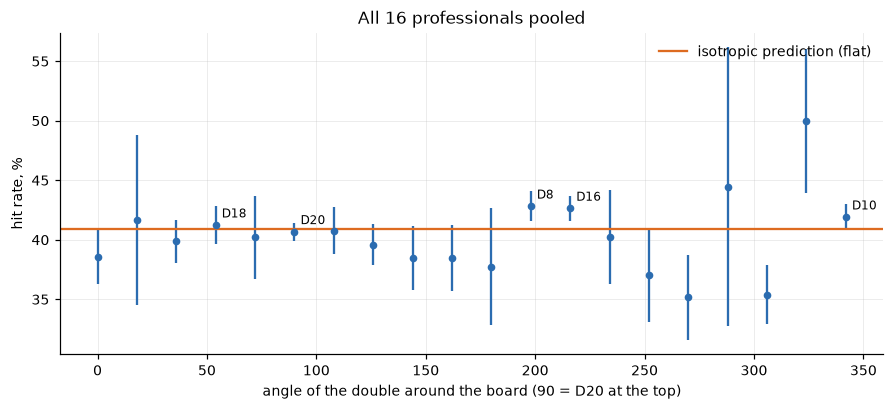

In [3]:
dd = dbl[dbl.double != 'DB'].copy()
dd['angle'] = dd.double.map(ANGLE)
pool = dd.groupby(['double', 'angle']).agg(attempts=('attempts', 'sum'),
                                           hits=('hits', 'sum')).reset_index()
pool['rate'] = pool.hits / pool.attempts
p0 = pool.hits.sum() / pool.attempts.sum()
exp_h = pool.attempts * p0
chi2 = (((pool.hits - exp_h) ** 2 / exp_h)
        + ((pool.attempts - pool.hits - (pool.attempts - exp_h)) ** 2
           / (pool.attempts - exp_h))).sum()
dof = len(pool) - 1
print(f'pooled hit rate {100*p0:.1f}% over {pool.attempts.sum():,} attempts')
print(f'homogeneity across all 20 doubles: chi2 = {chi2:.1f} on {dof} df, '
      f'p = {stats.chi2.sf(chi2, dof):.3f}')

# a null result means nothing without power. notebook 12's alternative is a
# cos(2*angle) pattern of peak-to-trough size A, so find the A this test catches
crit = stats.chi2.ppf(0.95, dof)
pat = np.cos(2 * np.deg2rad(pool.angle.values))
for A in np.arange(1.0, 20.0, 0.05):
    delta = A / 2 * pat / 100
    ncp = (pool.attempts.values * delta ** 2 / (p0 * (1 - p0))).sum()
    if stats.ncx2.sf(crit, dof, ncp) >= 0.8:
        break
print(f'power: a peak-to-trough spread of {A:.1f} pts would be caught 80% of the '
      f'time (notebook 12\'s 1.5:1 throw predicts 14)')

fig, ax = plt.subplots(figsize=(8.2, 3.8))
s = pool.sort_values('angle')
ax.errorbar(s.angle, 100 * s.rate,
            yerr=100 * np.sqrt(s.rate * (1 - s.rate) / s.attempts),
            fmt='o', ms=4, color='#2b6cb0')
ax.axhline(100 * p0, color='#dd6b20', lw=1.5, label='isotropic prediction (flat)')
for _, r in s[s.attempts > 900].iterrows():
    ax.annotate(r.double, (r.angle, 100 * r.rate), fontsize=8,
                textcoords='offset points', xytext=(4, 5))
ax.set_xlabel('angle of the double around the board (90 = D20 at the top)')
ax.set_ylabel('hit rate, %')
ax.set_title('All 16 professionals pooled')
ax.legend()
fig.tight_layout()

The flat line survives. Over 15,874 attempts the twenty doubles scatter by chi² = 20.8 on 19
degrees of freedom, p = 0.35 -- which is what a flat truth looks like.

A null result is worth only as much as the test's power, so that is measured too: this test
catches a peak-to-trough spread of **4.8 points** four times in five, and notebook 12's
1.5:1 tall throw predicts 14. So the pooled data rules out gross anisotropy in the average
professional. It says nothing about a 2-point wobble.

This was the model's most exposed prediction and it came through. It is also the one the
model makes for the dullest reason: a bed is a bed, and an isotropic Gaussian cannot tell
one orientation of the board from another.

In [4]:
# notebook 12's pre-specified direction: side doubles easier than top/bottom
dd['c2'] = np.cos(2 * np.deg2rad(dd.angle))
dd['band'] = np.where(dd.c2 > 0.5, 'side', np.where(dd.c2 < -0.5, 'top/bottom', None))
band = dd.dropna(subset=['band'])

rows = []
for player, s in band.groupby('player'):
    g = s.groupby('band').agg(a=('attempts', 'sum'), h=('hits', 'sum'))
    if set(g.index) != {'side', 'top/bottom'} or g.a.min() < 40:
        continue
    if min(g.h.min(), (g.a - g.h).min()) == 0:
        continue
    h1, n1 = g.loc['side', 'h'], g.loc['side', 'a']
    h2, n2 = g.loc['top/bottom', 'h'], g.loc['top/bottom', 'a']
    lor = np.log((h1 / (n1 - h1)) / (h2 / (n2 - h2)))
    se = np.sqrt(1 / h1 + 1 / (n1 - h1) + 1 / h2 + 1 / (n2 - h2))
    rows.append({'player': player, 'side n': int(n1), 'top/bot n': int(n2),
                 'side %': 100 * h1 / n1, 'top/bot %': 100 * h2 / n2,
                 'diff (pts)': 100 * (h1 / n1 - h2 / n2), 'log_or': lor, 'se': se})
per = pd.DataFrame(rows).sort_values('diff (pts)', ascending=False)
per['z'] = per.log_or / per.se
print(per[['player', 'side n', 'side %', 'top/bot n', 'top/bot %', 'diff (pts)', 'z']]
      .round(2).to_string(index=False))

w = 1 / per.se ** 2
mu = (w * per.log_or).sum() / w.sum()
Q = (w * (per.log_or - mu) ** 2).sum()
dof = len(per) - 1
side_tot = per['side n'] * per['side %'] / 100
tb_tot = per['top/bot n'] * per['top/bot %'] / 100
print(f'\npooled contrast: '
      f'{100*(side_tot.sum()/per["side n"].sum() - tb_tot.sum()/per["top/bot n"].sum()):+.1f} pts, '
      f'log OR {mu:+.3f}')
print(f'HETEROGENEITY across players: Q = {Q:.1f} on {dof} df, '
      f'p = {stats.chi2.sf(Q, dof):.4f}, I^2 = {max(0, 100*(Q-dof)/Q):.0f}%')
print('the isotropic model predicts every player\'s true contrast is exactly zero')

            player  side n  side %  top/bot n  top/bot %  diff (pts)     z
    Simon Whitlock     148   46.62        162      37.65        8.97  1.60
         Rob Cross     412   42.96        272      34.56        8.40  2.20
      Adrian Lewis     163   44.17        198      36.36        7.81  1.51
     Jonny Clayton     114   39.47        126      31.75        7.73  1.25
        James Wade     319   47.96        454      40.53        7.43  2.05
   Mensur Suljovic     372   40.86        259      36.29        4.57  1.16
Michael van Gerwen     542   44.65        594      41.08        3.57  1.22
         Ian White     219   38.36        356      35.96        2.40  0.58
     Michael Smith     346   43.06        602      42.19        0.87  0.26
      Daryl Gurney     384   41.41        288      40.97        0.43  0.11
      Peter Wright     379   43.01        456      42.98        0.03  0.01
     Dave Chisnall     268   39.18        400      40.75       -1.57 -0.41
   Nathan Aspinall     23

The average professional is isotropic. The individuals are not.

Pooled over all sixteen, the side-versus-top/bottom contrast is **+1.2 points** -- nothing,
which is why the previous test was flat. But the sixteen do not agree with each other:
**Q = 28.3 on 15 degrees of freedom, p = 0.020, I² = 47%**, so about half the spread between
players is real rather than sampling noise. The isotropic model predicts every one of those
sixteen numbers is exactly zero, and they run from Whitlock at +9.0 to Anderson at −13.0.

A null on average with heterogeneity underneath is exactly what notebook 12 predicts if
players have differently shaped groups. A tall group finds the side doubles easier and a
wide group finds the top and bottom easier; average over players and the two cancel. The
contrast is then not a nuisance but an *estimator*: its sign and size measure the player's
aspect ratio, from data that a scoresheet already contains. Cross, Whitlock, Lewis, Clayton
and Wade throw tall on this measure; Anderson, Cullen and Price throw wide.

No individual row is evidence on its own -- the largest is Anderson at z = −2.53, which does
not survive a correction for sixteen looks. The evidence is the heterogeneity.

One honest caveat. Players do not attempt all doubles equally, and a double taken often is a
double practised often. A within-player difference between bands can come from where a
player habitually finishes rather than from the shape of their group. Distinguishing the two
needs the attempt counts by double, which the data has -- but not in this notebook.

## Test 2: is a visit total what the model says?

Notebook 18 derived the visit-total distribution as an exact three-fold convolution. Here it
meets a real player's actual visits.

In [5]:
pv = pd.read_csv(os.path.join(DATA, 'per_visit.csv'), low_memory=False)
pv = pv[(pv.post_bust_visit == 0) & (pv.bust == 0) & (pv.darts_used == 3)]
pv = pv[(pv.score_before - pv.visit_score) >= SCORING_FLOOR]
# untruncated visits only, so the comparison needs no conditioning
un = pv[(pv.score_before - SCORING_FLOOR) >= 180]
who = un.groupby(['source', 'player']).size().idxmax()
s = un[(un.source == who[0]) & (un.player == who[1])]
obs = np.bincount(s.visit_score.values, minlength=181) / len(s)
print(f'{who[1]} ({who[0]}): {len(s):,} untruncated scoring visits, '
      f'mean {s.visit_score.mean():.1f}')

rows = []
for sig in (6.5, 7.0, 8.0):
    pmf = SV.visit_pmf(T20_MM, sig ** 2 * np.eye(2))
    rows.append({'sigma (mm)': sig, 'mean': (pmf * np.arange(181)).sum(),
                 'P(180) %': 100 * pmf[180], 'P(140+) %': 100 * pmf[140:].sum(),
                 'P(exactly 60) %': 100 * pmf[60], 'P(<=60) %': 100 * pmf[:61].sum()})
rows.append({'sigma (mm)': np.nan, 'mean': s.visit_score.mean(),
             'P(180) %': 100 * obs[180], 'P(140+) %': 100 * obs[140:].sum(),
             'P(exactly 60) %': 100 * obs[60], 'P(<=60) %': 100 * obs[:61].sum()})
n = len(s)
rows.append({'sigma (mm)': np.nan, 'mean': s.visit_score.std() / np.sqrt(n),
             **{k: 100 * np.sqrt(v * (1 - v) / n) for k, v in
                [('P(180) %', obs[180]), ('P(140+) %', obs[140:].sum()),
                 ('P(exactly 60) %', obs[60]), ('P(<=60) %', obs[:61].sum())]}})
t = pd.DataFrame(rows)
t.index = ['model 6.5', 'model 7.0', 'model 8.0', 'OBSERVED', '  +/- (1 se)']
t.round(2)

Peter Wright (dartsviz_pdc_2017): 1,367 untruncated scoring visits, mean 106.2


,sigma (mm),mean,P(180) %,P(140+) %,P(exactly 60) %,P(<=60) %
model 6.5,6.5,113.88,9.34,42.26,15.16,16.31
model 7.0,7.0,109.64,7.48,37.16,17.32,19.38
model 8.0,8.0,101.82,4.85,28.44,20.69,25.65
OBSERVED,NaN,106.18,8.05,32.04,10.53,19.97
+/- (1 se),NaN,1.02,0.74,1.26,0.83,1.08


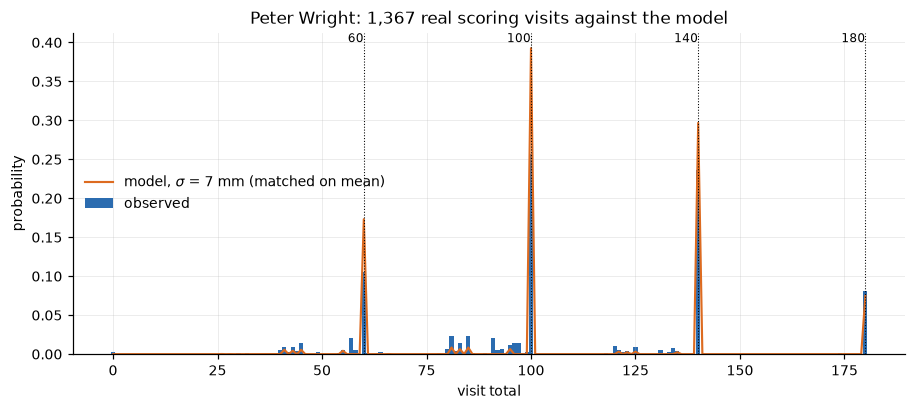

In [6]:
fig, ax = plt.subplots(figsize=(8.4, 3.8))
ax.bar(np.arange(181), obs, width=1.0, color='#2b6cb0', label='observed')
pmf7 = SV.visit_pmf(T20_MM, 7.0 ** 2 * np.eye(2))
ax.plot(np.arange(181), pmf7, lw=1.4, color='#dd6b20',
        label=r'model, $\sigma$ = 7 mm (matched on mean)')
for t_, lab in [(60, '60'), (100, '100'), (140, '140'), (180, '180')]:
    ax.axvline(t_, color='k', ls=':', lw=0.7)
    ax.annotate(lab, (t_, ax.get_ylim()[1]), fontsize=8, va='top', ha='right')
ax.set_xlabel('visit total'); ax.set_ylabel('probability')
ax.set_title(f'{who[1]}: {len(s):,} real scoring visits against the model')
ax.legend()
fig.tight_layout()

Matched on the three-dart average, the model needs σ ≈ 7.2 mm. At that setting it gets the
extremes right and the middle wrong.

Right: the 180 rate, 7.5% predicted against **8.05 ± 0.74** observed, and the rate of poor
visits, 19.4% against **19.97 ± 1.08**. Two independent checks at opposite ends of the
distribution, both passed by a σ fitted to neither.

Wrong: **P(exactly 60) is 17.3% predicted against 10.53 ± 0.83 observed** -- the model makes
that visit nearly twice as often as it happens, an eight-standard-error miss. P(140+) is out
by four. And no σ repairs it -- it makes it worse in either direction. P(exactly 60) *rises*
with σ, so reaching 10.5% needs a throw tighter than 6.5 mm, which would push the average
past 114 and the 180 rate past 9.3% and break both of the checks that just passed. One
parameter is setting the location and the spread at once, and the data wants them apart.

So the shape of a real player's scoring is not the shape of three independent draws from any
single Gaussian. The next test says why.

## Test 3: are the three darts independent?

This is the assumption, not a conclusion. Every transition matrix in this project treats a
visit as three i.i.d. draws around a fixed aim point; the MDP's whole state space is built
on it. It has never been checked, because until now there was no data to check it against.

The test is direct: does hitting the treble 20 with one dart change the chance of hitting it
with the next?

In [7]:
m = VIS[[1, 2, 3]].mean()
print(f'marginal P(T20): dart 1 {m[1]:.4f}   dart 2 {m[2]:.4f}   dart 3 {m[3]:.4f}\n')
for a, b in ((1, 2), (2, 3)):
    hit = VIS[VIS[a] == 1][b].mean(); miss = VIS[VIS[a] == 0][b].mean()
    n1 = int((VIS[a] == 1).sum()); n0 = int((VIS[a] == 0).sum())
    se = np.sqrt(hit * (1 - hit) / n1 + miss * (1 - miss) / n0)
    print(f'P(dart {b} = T20 | dart {a} hit T20)    {hit:.4f}   (n = {n1:,})')
    print(f'P(dart {b} = T20 | dart {a} missed)     {miss:.4f}   (n = {n0:,})')
    print(f'   lift {100*(hit-miss):+.2f} pts +/- {100*se:.2f}   z = {(hit-miss)/se:+.1f}\n')

k = VIS[[1, 2, 3]].sum(axis=1)
cnt = np.array([(k == i).sum() for i in range(4)], float)
obs_k = cnt / cnt.sum()
pbar = float(m.mean())
binom = np.array([stats.binom.pmf(i, 3, pbar) for i in range(4)])
tbl = pd.DataFrame({'observed %': 100 * obs_k, 'if independent %': 100 * binom,
                    'ratio': obs_k / binom}, index=[0, 1, 2, 3])
tbl.index.name = 'trebles in the visit'
chi = cnt.sum() * ((obs_k - binom) ** 2 / binom).sum()
print(f'chi2 = {chi:.0f} on 2 df, p = {stats.chi2.sf(chi, 2):.1e}')
tbl.round(2)

marginal P(T20): dart 1 0.2854   dart 2 0.2745   dart 3 0.2426

P(dart 2 = T20 | dart 1 hit T20)    0.4033   (n = 11,888)
P(dart 2 = T20 | dart 1 missed)     0.2231   (n = 29,761)
   lift +18.02 pts +/- 0.51   z = +35.3

P(dart 3 = T20 | dart 2 hit T20)    0.3827   (n = 11,433)
P(dart 3 = T20 | dart 2 missed)     0.1896   (n = 30,216)
   lift +19.31 pts +/- 0.51   z = +38.0

chi2 = 3910 on 2 df, p = 0.0e+00


,observed %,if independent %,ratio
trebles in the visit,,,
0,47.14,39.30,1.20
1,29.89,43.06,0.69
2,18.54,15.73,1.18
3,4.43,1.91,2.31


It is not close.

Hitting the treble 20 with the first dart nearly doubles the chance of hitting it with the
second: **40.3% against 22.3%, a lift of 18.02 ± 0.51 points, z = +35.3.** From the second
dart to the third it is **+19.31 ± 0.51, z = +38.0.** These are not marginal effects waiting
on a bigger sample. They are the largest signal in this notebook by an order of magnitude.

The damage to the model is in the table. Counting trebles per visit against a binomial with
the same marginal rate, the real distribution is **over-dispersed**: 20% too many visits with
no treble, 18% too many with two, **2.31× too many maximums**, all paid for by a 31%
shortfall in the exactly-one column. chi² = 3910 on 2 degrees of freedom. Real visits are
more all-or-nothing than three independent darts can be.

That over-dispersion *is* test 2's failure. The mean of a visit total and its spread are two
different things about a player, and three i.i.d. draws let σ control only one of them. A
player whose visits average 106 but arrive in a feast-or-famine pattern cannot be fitted by
any single Gaussian sampled three times, and the exactly-60 column is where the model's
tidiness shows up first.

(The marginal rate also decays through the visit, 28.5% → 27.5% → 24.3%. Part of that is the
filter, which bites hardest on the last dart of a big visit; the next section removes it.)

### Three things it could be instead

A positive correlation between darts does not by itself mean a player adjusts. Three duller
explanations have to be ruled out first, and all three are testable.

**Pooling players.** Strong players hit more trebles than weak ones, so mixing 158
professionals of different ability manufactures a correlation out of nothing. The fix is to
run the test inside each player.

**Slow form drift.** A player warms up, tires, plays a hard opponent. If their treble rate
wanders over an evening, darts near each other in time correlate whether or not anything
happens inside a visit. The fix is to compare *across* the gap between visits -- where the
player walks to the board, pulls their darts, and waits for their opponent -- against
*within* a visit. Drift crosses that gap; grooving does not.

**The filter itself.** Selecting visits by `score_before - total >= 250` conditions on a
function of all three darts, and conditioning on a sum couples its terms. The sign is known
in advance: the filter is an *upper* bound on the total, so a big first dart leaves less room
for the other two -- it manufactures *negative* dependence, not positive. The fix is to
restrict to visits starting at 430 or more, where a maximum of 180 cannot break the floor
and nothing is selected at all.

In [8]:
rows = []
for (src, player), s in VIS.groupby(['source', 'player']):
    if len(s) < 300:
        continue
    est, var = [], []
    for a, b in ((1, 2), (2, 3)):
        h = s[s[a] == 1][b]; mm_ = s[s[a] == 0][b]
        if len(h) < 30 or len(mm_) < 30:
            continue
        est.append(h.mean() - mm_.mean())
        var.append(h.mean() * (1 - h.mean()) / len(h)
                   + mm_.mean() * (1 - mm_.mean()) / len(mm_))
    if len(est) < 2:
        continue
    rows.append({'source': src.split('_')[0], 'player': player, 'visits': len(s),
                 'P(T20)': s[[1, 2, 3]].values.mean(),
                 'lift (pts)': 100 * np.mean(est), 'se': 100 * np.sqrt(sum(var)) / 2})
pp = pd.DataFrame(rows).sort_values('visits', ascending=False)
pp['z'] = pp['lift (pts)'] / pp.se
w = 1 / pp.se ** 2
print(f'{len(pp)} players with >= 300 pure-scoring visits')
print(f'positive lift: {(pp["lift (pts)"] > 0).sum()} of {len(pp)}   '
      f'sign test p = {stats.binomtest(int((pp["lift (pts)"] > 0).sum()), len(pp), 0.5).pvalue:.1e}')
print(f'inverse-variance pooled WITHIN-player lift: '
      f'{(w*pp["lift (pts)"]).sum()/w.sum():+.2f} pts +/- {np.sqrt(1/w.sum()):.2f}')
pp.head(12).round(2)

35 players with >= 300 pure-scoring visits
positive lift: 34 of 35   sign test p = 2.1e-09
inverse-variance pooled WITHIN-player lift: +18.88 pts +/- 0.45


,source,player,visits,P(T20),lift (pts),se,z
25,dartsviz,Peter Wright,2181,0.34,5.91,1.54,3.82
24,dartsviz,Michael van Gerwen,1650,0.30,28.99,1.75,16.60
6,dartsviz,Daryl Gurney,1407,0.27,33.28,1.97,16.92
27,dartsviz,Raymond van Barneveld,1364,0.31,10.89,1.95,5.58
30,dartsviz,Simon Whitlock,1089,0.22,30.92,2.32,13.30
26,dartsviz,Phil Taylor,1080,0.33,3.64,2.11,1.73
9,dartsviz,Gary Anderson,1060,0.32,23.01,2.16,10.66
7,dartsviz,Dave Chisnall,1022,0.30,26.95,2.26,11.93
21,dartsviz,Mensur Suljovic,986,0.30,8.77,2.31,3.79
10,dartsviz,Gerwyn Price,941,0.28,14.18,2.31,6.13


In [9]:
# within a visit against across the gap between visits
q = VIS.sort_values(['source', 'player', 'leg_id', 'visit_index']).copy()
q['next1'] = q.groupby(['source', 'player', 'leg_id'])[1].shift(-1)
q['gap'] = (q.groupby(['source', 'player', 'leg_id'])['visit_index'].shift(-1)
            - q['visit_index'])
adj = q[(q.gap == 2) & q.next1.notna()]        # visit_index alternates between players

def lift(a_flag, b_vals):
    h = b_vals[a_flag == 1].mean(); m_ = b_vals[a_flag == 0].mean()
    n1 = int((a_flag == 1).sum()); n0 = int((a_flag == 0).sum())
    return 100 * (h - m_), 100 * np.sqrt(h * (1 - h) / n1 + m_ * (1 - m_) / n0)

U = VIS[VIS.start >= SCORING_FLOOR + 180]      # the filter cannot bite here

rows = [('dart 1 -> dart 2, same visit', *lift(VIS[1], VIS[2])),
        ('dart 2 -> dart 3, same visit', *lift(VIS[2], VIS[3])),
        ('dart 1 -> dart 2, unfiltered visits only', *lift(U[1], U[2])),
        ("dart 3 -> next visit's dart 1", *lift(adj[3], adj.next1))]
out = pd.DataFrame(rows, columns=['transition', 'lift (pts)', 'se'])
out['z'] = out['lift (pts)'] / out.se
print(f'{len(adj):,} consecutive visit pairs by the same player in the same leg')
print(f'{len(U):,} visits starting at {SCORING_FLOOR + 180} or more')
out.round(2)

21,332 consecutive visit pairs by the same player in the same leg
26,141 visits starting at 430 or more


,transition,lift (pts),se,z
0,"dart 1 -> dart 2, same visit",18.02,0.51,35.29
1,"dart 2 -> dart 3, same visit",19.31,0.51,38.05
2,"dart 1 -> dart 2, unfiltered visits only",22.33,0.63,35.58
3,dart 3 -> next visit's dart 1,-6.83,0.70,-9.79


All three alternatives fail, and the third fails informatively.

**Not pooling.** Inside each of the 35 players with at least 300 pure-scoring visits, **34
of 35** show a positive lift -- sign test p = 2 × 10⁻⁹ -- and the inverse-variance pooled
within-player estimate is **+18.88 ± 0.45**, indistinguishable from the +18.02 measured
across everybody at once. Mixing abilities contributes essentially nothing. This is not
Simpson's paradox.

**Not drift.** Across the gap between a player's own consecutive visits the lift is
**−6.83 points, z = −9.8**. Form drift would carry across that gap; instead the sign flips.
Whatever couples the darts is spent by the time the player has walked to the board, pulled
their darts, and come back.

**Not the filter.** Restricted to the 26,141 visits starting at 430 or more -- where a
maximum cannot break the floor, so nothing is selected -- the lift is **+22.33**, larger than
the +18.02 measured on everything. The filter was *suppressing* the effect, exactly as the
sign argument said it would. The same argument accounts for the negative number above: a big
visit leaves the next one closer to the floor, where the filter bites.

What is left is a real, within-visit effect, and it varies enormously between players: from
Taylor's **+3.64 ± 2.11** (not significant on 1,080 visits) to Gurney's **+33.28**. It is
not a constant of the game and it does not track scoring ability -- Wright and Taylor hit
the most trebles and show the least lift, but Anderson and van Gerwen hit nearly as many and
show five times more.

## Verdict

Three predictions, three different answers.

**Every double equally hard — survives, on average.** Sixteen professionals and 15,874
attempts give a flat board to within noise (p = 0.35), in a test with 80% power against a
5-point spread. Underneath, the players disagree with each other in both directions
(I² = 47%, p = 0.020). That is less a refutation than an invitation: notebook 12 says the
sign of the side-versus-top contrast measures a player's aspect ratio, and here it is,
measurable from a scoresheet.

**The visit total — right at the extremes, wrong in the middle.** Matched on a real player's
average, the model reproduces his 180 rate and his rate of poor visits, then predicts an
exact 60 nearly twice as often as it happens. No σ fixes it, because σ sets the mean and the
spread together.

**Independent darts — refuted, decisively, and it was never a conclusion.** Hitting the
treble 20 lifts the next dart's chance of doing the same by 18 to 22 points: z above 35,
reproduced within 34 of 35 individual players, absent across the gap between visits, and
*larger* once the selection filter is removed. Every transition matrix in this project is
built on three i.i.d. draws around a fixed aim point. That is not what a visit is.

### What it costs, and what it does not

The dependence lives inside a visit and is gone by the next one, which localises the damage.

- **Per-dart quantities stand.** Where to aim for a given score, what a millimetre of
  improvement is worth (08), which target measures a player best (09), how the optimal
  target moves with ability (03) — these read the one-dart distribution, and nothing here
  contradicts it.
- **Anything reading the spread of a visit total does not.** Checkout probability from a
  given score, bust risk, the value of the throw (04, 06) and the ability-tailored checkout
  charts (05) all depend on the tail of a visit distribution the model makes too thin. The
  direction of the error is known: real visits are more all-or-nothing, so a player is both
  likelier to be left short and likelier to clear a big number than the model says.
- **Every error bar in the fitting notebooks is too narrow.** Notebooks 07, 15 and 18 form
  likelihoods by multiplying over darts. Positively correlated observations carry less
  information than their count suggests, so the point estimates are roughly safe and the
  intervals are not. Notebook 10's "233 darts for an elite player, 4,857 for a pub player"
  are counts of nominally independent darts; if darts arrive in correlated threes, the true
  requirement is larger.

### The obvious fix

One extra parameter reproduces everything measured here. Let the **aim point be drawn once
per visit** — the stance, the grip, the rhythm the player has for those three darts — and
let the darts be conditionally independent around it. Then:

- darts within a visit correlate positively, because they share a draw;
- darts in different visits do not, because the draw is refreshed at the oche;
- the visit total is over-dispersed at the same mean, with the exactly-one-treble column
  hollowed out and both ends filled in;
- and notebook 18's three-fold convolution still holds *conditionally*, so the calibration
  machinery survives — the visit pmf becomes a mixture of convolutions over the offset.

That is a two-level model with a within-visit σ and a between-visit σ, and both are
identifiable from exactly the data used here: the within-visit lift pins their ratio, the
marginal treble rate pins the total. It is the natural next notebook — and it is the first
time in this project that the data, rather than a guess about what might matter, has said
which parameter to add.